# Region boundaries and budgets on the ECCO LLC90 lat-lon-cap grid

This example applies `regionate` to the **ECCOv4r4 native lat-lon-cap (LLC90)** grid -- a
genuinely *multi-tile* ocean grid whose 13 tiles are connected by an `xgcm`
`face_connections` topology (with rotated seams and an Arctic "cap"). It

1. traces the **Atlantic basin** into grid-conforming boundary loops spanning many tiles;
2. verifies that the traced boundary obeys the **discrete divergence theorem** (the property
   that makes region budgets consistent with boundary fluxes) over the *whole* basin; and
3. builds a **latitude-circle** section across the basin (`curve="latitude circle"`).

The grid is loaded natively (MITgcm 'left'-staggered vorticity points), which `sectionate`
supports directly.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from load_example_ECCO_grid import load_ECCO_LLC90_grid, atlantic_basin_mask
from regionate import MaskRegions
import sectionate as sec

grid = load_ECCO_LLC90_grid()
grid

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   i --> left
  * left     i_g --> center
Y Axis (not periodic, boundary='fill'):
  * center   j --> left
  * left     j_g --> center

## The Atlantic basin mask

We use the published **Natural Earth ocean basins** via `regionmask` (the open Atlantic is
split into several named basins -- North/South Atlantic, Sargasso Sea, Caribbean, etc. -- so
we union the Atlantic-sector basins; see `ATLANTIC_BASINS`). Published basin polygons keep
the mask geographically correct: it follows the coastlines, fills the central Atlantic, and
excludes the Pacific.

In [2]:
atlantic = atlantic_basin_mask(grid)
lon, lat = grid._ds["geolon"], grid._ds["geolat"]
tiles_in_mask = sorted(set(np.where(atlantic.values.any(axis=(1, 2)))[0].tolist()))
print(f"Atlantic ocean cells: {int(atlantic.sum())}  spanning tiles: {tiles_in_mask}")

Atlantic ocean cells: 11284  spanning tiles: [0, 1, 2, 10, 11, 12]


## Trace the basin boundary

`MaskRegions` traces the mask into one or more closed boundary loops. The basin perimeter is
the largest loop; smaller loops are islands / interior coastline, plus a few cells that touch
the main basin only at a corner (diagonally) and so form their own tiny loops. Together the
loops enclose **every** masked cell. Each loop carries a per-corner face index `f_c` that
spans every tile the boundary touches -- the loops are stitched across the rotated tile seams
and the cap.

In [3]:
regions = MaskRegions(atlantic, grid).region_dict
loops = sorted(regions.values(), key=lambda r: len(r.lons_c), reverse=True)
perimeter = loops[0]
print(f"boundary loops (perimeter + islands + diagonal fragments): {len(loops)}")
print(f"basin perimeter: {len(perimeter.lons_c)} corners, "
      f"spanning tiles {sorted(set(np.asarray(perimeter.f_c).tolist()))}")

boundary loops (perimeter + islands + diagonal fragments): 18
basin perimeter: 922 corners, spanning tiles [0, 1, 2, 10, 11, 12]


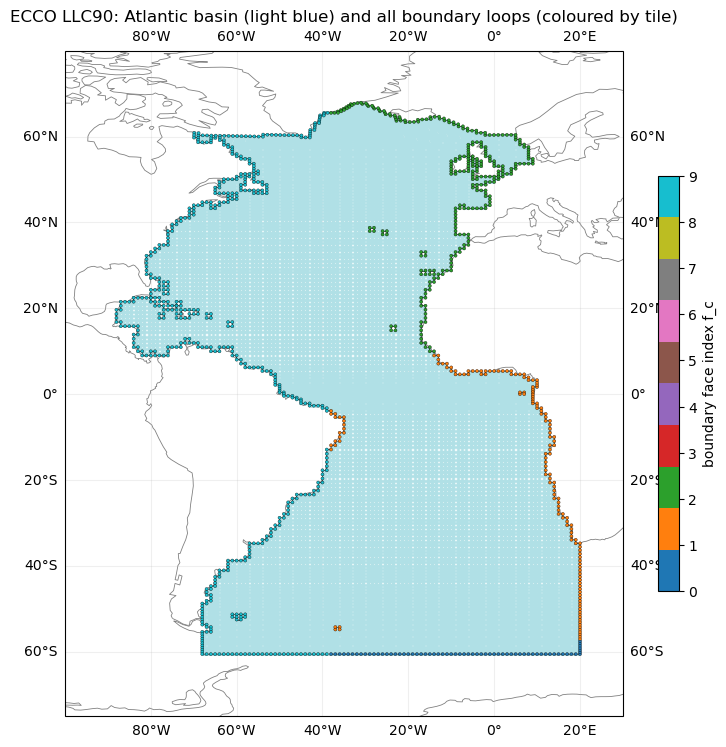

In [4]:
fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-100, 30, -75, 80], crs=ccrs.PlateCarree())
ax.coastlines(color="0.5", linewidth=0.6)
ax.gridlines(draw_labels=True, alpha=0.2)

# interior masked cells: one muted colour, larger filled dots
for t in tiles_in_mask:
    mt = atlantic.isel(tile=t).values
    ax.scatter(lon.isel(tile=t).values[mt], lat.isel(tile=t).values[mt],
               s=7, color="powderblue", zorder=2)

# ALL boundary loops: a different (categorical-by-tile) colour map, smaller points
# with thin black edges -- so every masked cell lies inside some drawn loop.
for r in loops:
    ax.plot(r.lons_c, r.lats_c, "-", color="k", lw=0.4, zorder=4)
    sc = ax.scatter(r.lons_c, r.lats_c, c=np.asarray(r.f_c)[:len(r.lons_c)],
                    cmap="tab10", vmin=0, vmax=9, s=5, zorder=5,
                    edgecolor="k", linewidth=0.25)
plt.colorbar(sc, ax=ax, label="boundary face index f_c", shrink=0.6)
ax.set_title("ECCO LLC90: Atlantic basin (light blue) and all boundary loops (coloured by tile)")
plt.show()

## Budget consistency: the discrete divergence theorem

The point of a grid-consistent boundary is that **region budgets balance the fluxes through
the boundary**: for any quantity whose transports live on the staggered velocity faces, the
net flux through the region boundary equals the flux convergence summed over the region's
cells. We check this **on the whole Atlantic basin** (all loops, across rotated seams) using
an arbitrary synthetic transport field `(umo, vmo)`.

One subtlety: the cell-centred convergence of a *velocity* field must be taken with xgcm's
**vector-aware** operator `grid.diff_2d_vector`. Across a 90-degree LLC seam the U-component
rotates into the neighbour tile's V-component, so differencing each component as an
independent scalar (`grid.diff(umo,"X") + grid.diff(vmo,"Y")`) would be wrong at those seams;
`diff_2d_vector` rotates the components correctly (see xgcm's vector-padding docs).

In [5]:
# arbitrary synthetic transports on the staggered velocity faces (U on i_g, V on j_g)
nf, ny, nx = (grid._ds.sizes[d] for d in ("tile", "j", "i"))
g = np.arange(nf * ny * nx, dtype=float).reshape(nf, ny, nx)
umo = xr.DataArray(np.sin(g * 0.013) + 0.3, dims=("tile", "j", "i_g"))
vmo = xr.DataArray(np.cos(g * 0.017) - 0.2, dims=("tile", "j_g", "i"))

# (a) flux convergence over the region cells, with the vector-aware divergence
div = grid.diff_2d_vector({"X": umo, "Y": vmo}, to="center", boundary="fill", fill_value=np.nan)
convergence = float((-(div["X"] + div["Y"])).where(atlantic, 0.).sum())

# (b) net flux through every traced boundary face, summed over ALL of the basin's loops
U = umo.transpose("tile", ...).values
V = vmo.transpose("tile", ...).values
boundary_flux = 0.0
for r in regions.values():
    uv = sec.uvindices_from_qindices(grid, r.i_c, r.j_c, f_c=r.f_c)
    for k in range(len(uv["var"])):
        if uv["var"][k] == "0":
            continue
        f, i, j = int(uv["face"][k]), int(uv["i"][k]), int(uv["j"][k])
        t = U[f, j, i] if uv["var"][k] == "U" else V[f, j, i]
        boundary_flux += int(uv["Lsign"][k]) * t

print(f"flux convergence over basin cells = {convergence:.10f}")
print(f"net flux through boundary faces   = {boundary_flux:.10f}")
print(f"divergence-theorem residual       = {convergence - boundary_flux:.2e}")

flux convergence over basin cells = -82.9180079569
net flux through boundary faces   = -82.9180079569
divergence-theorem residual       = 1.42e-14


The residual is at the level of floating-point round-off: `regionate`'s boundary faces are
*exactly* the velocity faces that separate in-mask from out-of-mask cells -- everywhere,
including across the rotated tile seams -- so the discrete divergence theorem holds over the
entire basin. This is what makes a regional volume/heat/mass budget on this region close.

(With real ECCO velocity output one would feed the same boundary indices to
`sectionate.convergent_transport`, which performs this boundary integral directly.)

## Notes

- regionate traces the boundary face-by-face with `contourpy`, removes internal tile-seam
  faces (in-mask on both sides), and stitches the remaining open arcs across seams using the
  grid topology (cell adjacency) -- no reliance on coordinate coincidence, so rotated/reversed
  seams and the cap are handled uniformly.
- The native 'left' MITgcm/ECCO staggering is consumed directly via `sectionate.gridutils`
  (`corner_position`/`corner_offset`); the same code path handles symmetric ('outer') and
  'right' grids.